In [1]:
#!/usr/bin/python
import matplotlib.pyplot as plt
import LRT_fxnlib as LRTlib
import pandas as pd
import numpy as np

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

In [2]:
# For thesis stuff (not necessary for LRT calculations)
import xarray as xr
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as pipelinelib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

# Calculate the contrail LW and SW radiative fluxes

## LW

### LW contrail calculation

In [ ]:
# LW flux calculation
LW_contrail = LRTlib.calculate_LW_Flux(LW_contrail_options, True)
LW_clearsky = LRTlib.calculate_LW_Flux(LW_clearsky_options, False)
LW_RF = LW_contrail-LW_clearsky
print("Longwave Radiative Forcing (W/m^2): ", LW_RF)
print(f"LW_contrail: {LW_contrail}, LW_clearsky: {LW_clearsky}")

## SW

### SW contrail calculation

In [ ]:
# SW flux calculation
SW_contrail = LRTlib.calculate_SW_Flux(SW_contrail_options, True)
SW_clear = LRTlib.calculate_SW_Flux(SW_clearsky_options, False)

SW_RF = SW_contrail - SW_clear
print("Shortwave Radiative Forcing (mW/m^2): ", SW_RF)
print(f"SW_contrail: {SW_contrail}, SW_clearsky: {SW_clear}")

# Sensitivity Studies (incomplete, ignore)

### Snes

In [ ]:
# from sklearn.linear_model import LinearRegression

# # Filter data for y <= 20
# mask_regression = y_values_filtered <= 20
# tau_regression = tau_plot_filtered[mask_regression].reshape(-1, 1)
# y_regression = y_values_filtered[mask_regression]

# # Perform linear regression
# regressor = LinearRegression()
# regressor.fit(tau_regression, y_regression)

# # Generate regression line
# tau_line = np.linspace(tau_regression.min(), tau_regression.max(), 100).reshape(-1, 1)
# y_line = regressor.predict(tau_line)

# # Plot the regression line
# fig, ax = plt.subplots(dpi=100)
# ax.scatter(tau_plot_filtered, y_values_filtered, s=10, color='black')  # Original data points
# ax.plot(tau_line, y_line, color='red', label='Linear Regression')  # Regression line

# # Highlight areas
# ax.fill_between(tau_plot_filtered, 0, 20, color='blue', alpha=0.2, label='Individual Contrails')
# ax.fill_between(tau_plot_filtered, 20, 80, color='orange', alpha=0.2, label='Contrail Cirrus')

# # Add labels and formatting
# ax.set_title("LibRadTran Contrail Radiative Forcing Estimates")
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}'))

# ax.set_xlabel(xlabel=r"Lifetime Integrated Optical Depth")
# ax.set_ylabel(ylabel=r"Radiative Forcing $[mW/m^2]$")
# ax.legend()

In [ ]:
# print("Slope of the linear regression:", regressor.coef_[0])
# # Calculate the change in x required to increase the radiative forcing by 1 mW/m^2
# current_rf = y_regression[-1]  # Current radiative forcing
# target_rf = current_rf + 1  # Target radiative forcing (1 mW/m^2 increase)
# required_change_in_x = (target_rf - regressor.intercept_) / regressor.coef_[0] - tau_regression[-1]
# print("Change in x required to increase radiative forcing by 1 mW/m^2:", required_change_in_x[0])

### Compute PCE test 31 radiative forcing + error bars

In [7]:
### Function Library ###
def make_LW_options(habit, hour):
    LW_contrail_options_BASE = [
        ["data_files_path", "data", "Location of libRadtran data files"],
        ["source", "thermal", "Calculate the longwave radiation"],
        ["latitude", "N 45", "Latitude of the location"],
        ["longitude", "W 45", "Longitude of the location"],
        ["time", f"2025 6 29 {hour} 0 0", "Local time YYYY MM DD hh mm ss"], # Noon at 45N, 45W on June 29, 2025 : "2025 6 29 12 0 0", # 3 PM at 45N, 45W on June 29, 2025 : "2025 6 29 15 0 0", Midnight at 45N, 45W on June 29, 2025 : "2025 6 29 0 0 0"
        ["albedo", "0.2", "Surface albedo"],
        ["rte_solver", "disort", "Radiative transfer equation solver"],
        ["mol_abs_param", "reptran", "Fine structure parameter"],
        ["number_of_streams", "6", "Number of streams"],
        ["wavelength", "2500 80000", "Wavelength range [nm]"],
        ["zout", "TOA", "Sum at the top of atmosphere"],
        ["ic_file", "1D ice.in", "Ice properties input file"],
        ["ic_properties", "yang", "Ice properties"],
        ["ic_habit", "OVERWRITE", "Ice habit"],
        ["ic_modify", "tau set OVERWRITE", "Set optical depth"],
        ["output_process", "integrate", "Spectrally integrate the output"],
        ["output_user", "edir eglo edn eup enet esum", "Return the direct, global, diffuse downward, and diffuse upward irradiance. Net is global - upward, sum is global + upward."],
        ["quiet", "", ""]
    ]
    if habit == "ghm":
        LW_contrail_options = LW_contrail_options_BASE.copy()
        for i, option in enumerate(LW_contrail_options):
            if option[0] == "ic_habit":
                LW_contrail_options[i][1] = habit
            if option[0] == "ic_properties":
                LW_contrail_options[i][0] = "ic_properties"
                LW_contrail_options[i][1] = "baum_v36 interpolate"
                LW_contrail_options[i][2] = "Ice properties"

    elif habit == "solid-column":
        LW_contrail_options = LW_contrail_options_BASE.copy()
        for i, option in enumerate(LW_contrail_options):
            if option[0] == "ic_habit":
                LW_contrail_options[i][1] = habit

    else:
        raise ValueError("Habit must be either 'ghm' or 'solid-column'.")
        
    LW_contrail_options = pd.DataFrame(LW_contrail_options, columns=["Name", "Value", "Description"])
    LW_clearsky_options = LW_contrail_options[~LW_contrail_options["Name"].str.startswith("ic_")].reset_index(drop=True)
    
    return LW_contrail_options, LW_clearsky_options

def make_SW_options(LW_contrail_options):
    # Define input options: [Name, Value, Description]
    # SW is the same as LW except for the source and wavelength
    SW_contrail_options = LW_contrail_options.copy()
    SW_contrail_options.loc[SW_contrail_options["Name"] == "source", ["Value", "Description"]] = ["solar data/solar_flux/atlas_plus_modtran", "Calculate the shortwave radiation, Location of the extraterrestrial spectrum"]
    SW_contrail_options.loc[SW_contrail_options["Name"] == "wavelength", ["Value", "Description"]] = ["299 341", "Wavelength range [nm]"]

    # Clearsky is the same as contrail except for the ice cloud properties
    SW_clearsky_options = SW_contrail_options[~SW_contrail_options["Name"].str.startswith("ic_")].reset_index(drop=True)

    return SW_contrail_options, SW_clearsky_options

# Calculate the vertical integrated optical depth for each time step with an associated contrail width
def calculate_LLES_tau(S, W):
    tau = 0.5*S/W
    return tau

def get_weights(r):
    # Convert to micrometers from meters
    r = r * 1e6

    if r < 5:
        weights = habit_weights[0]
    elif 5 <= r < 9.5:
        weights = habit_weights[1]
    elif 9.5 <= r < 23:
        weights = habit_weights[2]
    elif 23 <= r < 190:
        weights = habit_weights[3]
    else: # r >= 190
        weights = habit_weights[4]
    return np.array(weights)

def calculate_sauter_mean(particle_sizes, frequencies):
    """
    Calculates the Sauter Mean Diameter (D[3,2]) for a particle size distribution.

    Args:
        particle_sizes (list or numpy array): A list or array of particle sizes.
        frequencies (list or numpy array): A list or array of corresponding frequencies
                                           or probabilities for each particle size.

    Returns:
        float: The Sauter Mean Diameter (D[3,2]).
    """
    # Ensure inputs are numpy arrays for easier element-wise operations
    particle_sizes = np.array(particle_sizes)
    frequencies = np.array(frequencies)

    # Calculate the third moment (sum of (size^3 * frequency))
    third_moment = np.sum(particle_sizes**3 * frequencies)

    # Calculate the second moment (sum of (size^2 * frequency))
    second_moment = np.sum(particle_sizes**2 * frequencies)

    # Calculate the Sauter Mean Diameter (ratio of third moment to second moment)
    sauter_mean = third_moment / second_moment

    return sauter_mean

def calculate_RF(times, tau, depth, radii, habit, hour):
    print(f"Calculating LW and SW RF for dataset with habit: {habit}...")

    LW_RF = np.zeros(len(times))
    SW_RF = np.zeros(len(times))

    if habit == "solid-column":
        min_radius = 5.96 # Minimum radius for solid-column to comply with mechanism minimum [um]
    elif habit == "ghm":
        min_radius = 5.1 # Minimum radius for ghm to comply with mechanism minimum [um]

    for i in range(len(times)):
        # Define LW inputs
        LW_contrail_options_cocip, LW_clearsky_options_cocip = make_LW_options(habit, hour)
        # Modify the tau in the LW options
        LW_contrail_options_cocip.loc[LW_contrail_options_cocip["Name"] == "ic_modify", "Value"] = f"tau set {tau[i]}"
        print(f"Calculating RF for time {times[i]:.2f} hours with tau: {tau[i]:.4f}, depth: {depth[i]:.2f} [m], radius: {radii[i]:.2f} [um]")
    
        # Define SW inputs
        SW_contrail_options_cocip, SW_clearsky_options_cocip = make_SW_options(LW_contrail_options_cocip)
        # Modify the tau in the SW options
        SW_contrail_options_cocip.loc[SW_contrail_options_cocip["Name"] == "ic_modify", "Value"] = f"tau set {tau[i]}"
    
        # Update the effective radius and contrail depth in the ice.in file
        ice_in_file = "/home/chinahg/GCresearch/contrailuncertainty/LRT/ice.in"
        with open(ice_in_file, "r") as f:
            ice_in_content = f.readlines()
        
        # Update the effective radius line (4th line, index 3)
        # Ensure minimum radius of 5.96 um for solid-column to comply with mechanism minimum
        if radii[i] < min_radius:
            radius = min_radius
        else:
            radius = radii[i]

        # Update the contrail depth line (4th line, index 3)
        contrail_depth = 10.7 - depth[i]/1000 # Convert from [m] to [km]

        ice_in_content[3] = f"{contrail_depth:.3f} " + ice_in_content[3].split()[1] + f" {radius:.3f}"
        with open(ice_in_file, "w") as f:
            f.writelines(ice_in_content)
        print(f"Updated ice.in file with contrail depth: {contrail_depth:.3f} [m]")
        print(f"Updated ice.in file with effective radius: {radius:.3f} [um]")

        # LW flux calculation
        LW_RF[i] = np.abs(LRTlib.calculate_LW_Flux(LW_contrail_options_cocip, True) - LRTlib.calculate_LW_Flux(LW_clearsky_options_cocip, False))
        # SW flux calculation
        SW_RF[i] = np.abs(LRTlib.calculate_SW_Flux(SW_contrail_options_cocip, True) - LRTlib.calculate_SW_Flux(SW_clearsky_options_cocip, False))
        
        print(f"Calculated LW RF: {LW_RF[i]:.4f} W/m^2, SW RF: {SW_RF[i]:.4f} W/m^2\n")

        # Save the times and LW radiation forcing values to a csv
        LW_RF_df = pd.DataFrame({
            "Contrail_Age_hours": times,
            "LW_Radiative_Forcing_W_m2": LW_RF
        })

        # Save the times and SW radiation forcing values to a csv
        SW_RF_df = pd.DataFrame({
            "Contrail_Age_hours": times,
            "SW_Radiative_Forcing_W_m2": SW_RF
        })

    return LW_RF_df, SW_RF_df

In [8]:
### APCEMM BYPASS DATASET ###
APCEMM_data = pipelinelib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1')
APCEMM_ds = APCEMM_data.ds_t
n_bins = 38

# Import novel min and max VOD values from csv
novel_min = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/start_here/novel_vod_bounds.csv')['novel_min'].values
novel_max = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/start_here/novel_vod_bounds.csv')['novel_max'].values
novel_true = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/start_here/novel_vod_bounds.csv')['novel_true'].values

# Extract integrated optical depth and width, handle erroneous values
APCEMM_widths = np.zeros(len(APCEMM_ds)) # [m]
APCEMM_depth = np.zeros(len(APCEMM_ds)) # [m]
APCEMM_radii_bins = APCEMM_ds[0]['r'].values*1e6 # [um]
APCEMM_radii_counts = np.zeros((n_bins, len(APCEMM_ds)))

for i in range(len(APCEMM_ds)):
    width = APCEMM_ds[i]['width'].values.item()
    if i > 0 and width == 0:
        width = APCEMM_widths[i-1]
    APCEMM_widths[i] = width

    APCEMM_radii_counts[:, i] = APCEMM_ds[i]["Overall size distribution"].values
    APCEMM_depth[i] = APCEMM_ds[i]['depth'].values.item()

# Calculate tau and times
APCEMM_tau_min = np.array([OD_min / width for OD_min, width in zip(novel_min, APCEMM_widths)])
APCEMM_tau_max = np.array([OD_max / width for OD_max, width in zip(novel_max, APCEMM_widths)])
APCEMM_tau_true = np.array([OD_true / width for OD_true, width in zip(novel_true, APCEMM_widths)])
APCEMM_times = np.arange(73) * 10 / 60  # time in hours (10 min per step)

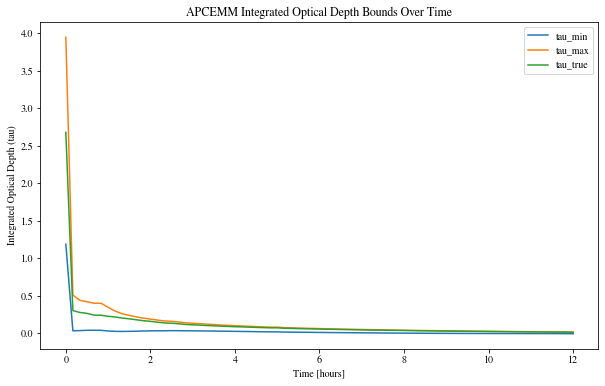

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(APCEMM_times, APCEMM_tau_min, label='tau_min')
plt.plot(APCEMM_times, APCEMM_tau_max, label='tau_max')
plt.plot(APCEMM_times, APCEMM_tau_true, label='tau_true')
plt.xlabel('Time [hours]')
plt.ylabel('Integrated Optical Depth (tau)')
plt.title('APCEMM Integrated Optical Depth Bounds Over Time')
plt.legend()
plt.show()

In [11]:
# Calculate the effective radius using the radio of the 2nd and 3rd moment of the radius distribution
APCEMM_radii = np.zeros(len(APCEMM_times))

for p in range(len(APCEMM_times)):
    APCEMM_radii[p] = calculate_sauter_mean(APCEMM_radii_bins, APCEMM_radii_counts[:, p]) # in [um]

hour = '0'
habit_type = 'ghm'

for bound in ['lower', 'upper', 'true']:
    if bound == 'lower':
        APCEMM_tau = APCEMM_tau_min
    elif bound == 'upper':
        APCEMM_tau = APCEMM_tau_max
    elif bound == 'true':
        APCEMM_tau = APCEMM_tau_true
    else:
        raise ValueError("Bound must be either 'lower', 'upper', or 'true'.")

    # Calculate RF
    print(f"Calculating RF for {habit_type} at {hour}h, {bound} bound...")
    LW_RF_APCEMM, SW_RF_APCEMM = calculate_RF(APCEMM_times, APCEMM_tau, APCEMM_depth, APCEMM_radii, habit_type, hour)

    # Save to csv
    SW_RF_APCEMM.to_csv(
        f"/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/SW_RF_APCEMM_{habit_type}_{hour}h_{bound}.csv",
        index=False
    )
    print(f"SW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/SW_RF_APCEMM_{habit_type}_{hour}h_{bound}.csv.")

    # Save to csv
    LW_RF_APCEMM.to_csv(
        f"/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/LW_RF_APCEMM_{habit_type}_{hour}h_{bound}.csv",
        index=False
    )
    print(f"LW RF results saved to /home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/LW_RF_APCEMM_{habit_type}_{hour}h_{bound}.csv.")


Calculating RF for ghm at 0h, lower bound...
Calculating LW and SW RF for dataset with habit: ghm...
Calculating RF for time 0.00 hours with tau: 1.1875, depth: 128.33 [m], radius: 1.95 [um]
Updated ice.in file with contrail depth: 10.572 [m]
Updated ice.in file with effective radius: 5.100 [um]
Calculated LW RF: 71.1988 W/m^2, SW RF: 0.0000 W/m^2

Calculating RF for time 0.17 hours with tau: 0.0348, depth: 231.00 [m], radius: 6.81 [um]
Updated ice.in file with contrail depth: 10.469 [m]
Updated ice.in file with effective radius: 6.813 [um]
Calculated LW RF: 3.8955 W/m^2, SW RF: 0.0000 W/m^2

Calculating RF for time 0.33 hours with tau: 0.0370, depth: 266.00 [m], radius: 9.31 [um]
Updated ice.in file with contrail depth: 10.434 [m]
Updated ice.in file with effective radius: 9.310 [um]
Calculated LW RF: 3.9382 W/m^2, SW RF: 0.0000 W/m^2

Calculating RF for time 0.50 hours with tau: 0.0412, depth: 308.00 [m], radius: 11.69 [um]
Updated ice.in file with contrail depth: 10.392 [m]
Updated 

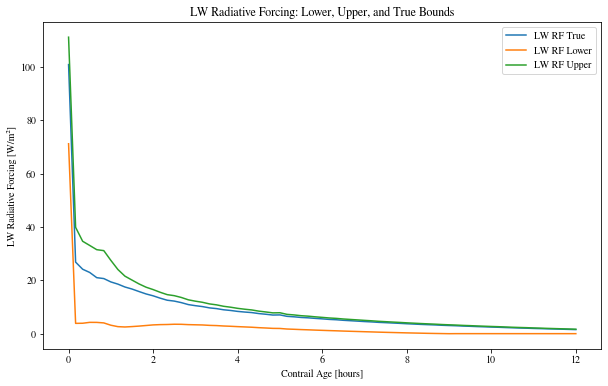

the 3 datasets are identical:  False


In [12]:
LW_RF_APCEMM = pd.read_csv(
    "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/LW_RF_APCEMM_ghm_0h_true.csv"
)
LW_RF_APCEMM_lower = pd.read_csv(
    "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/LW_RF_APCEMM_ghm_0h_lower.csv"
)
LW_RF_APCEMM_upper = pd.read_csv(
    "/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_data_sets/test_30/outputs/validation/test_30_run_1/LW_RF_APCEMM_ghm_0h_upper.csv"
)
plt.figure(figsize=(10, 6))
plt.plot(LW_RF_APCEMM['Contrail_Age_hours'], LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'], label='LW RF True')
plt.plot(LW_RF_APCEMM_lower['Contrail_Age_hours'], LW_RF_APCEMM_lower['LW_Radiative_Forcing_W_m2'], label='LW RF Lower')
plt.plot(LW_RF_APCEMM_upper['Contrail_Age_hours'], LW_RF_APCEMM_upper['LW_Radiative_Forcing_W_m2'], label='LW RF Upper')
plt.xlabel('Contrail Age [hours]')
plt.ylabel('LW Radiative Forcing [W/m²]')
plt.title('LW Radiative Forcing: Lower, Upper, and True Bounds')
plt.legend()
plt.show()

print("the 3 datasets are identical: ", np.array_equal(LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'], LW_RF_APCEMM_lower['LW_Radiative_Forcing_W_m2']) and np.array_equal(LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'], LW_RF_APCEMM_upper['LW_Radiative_Forcing_W_m2']))

<!-- ## Calculate contrail LW flux for multiple optical depths (tau) -->

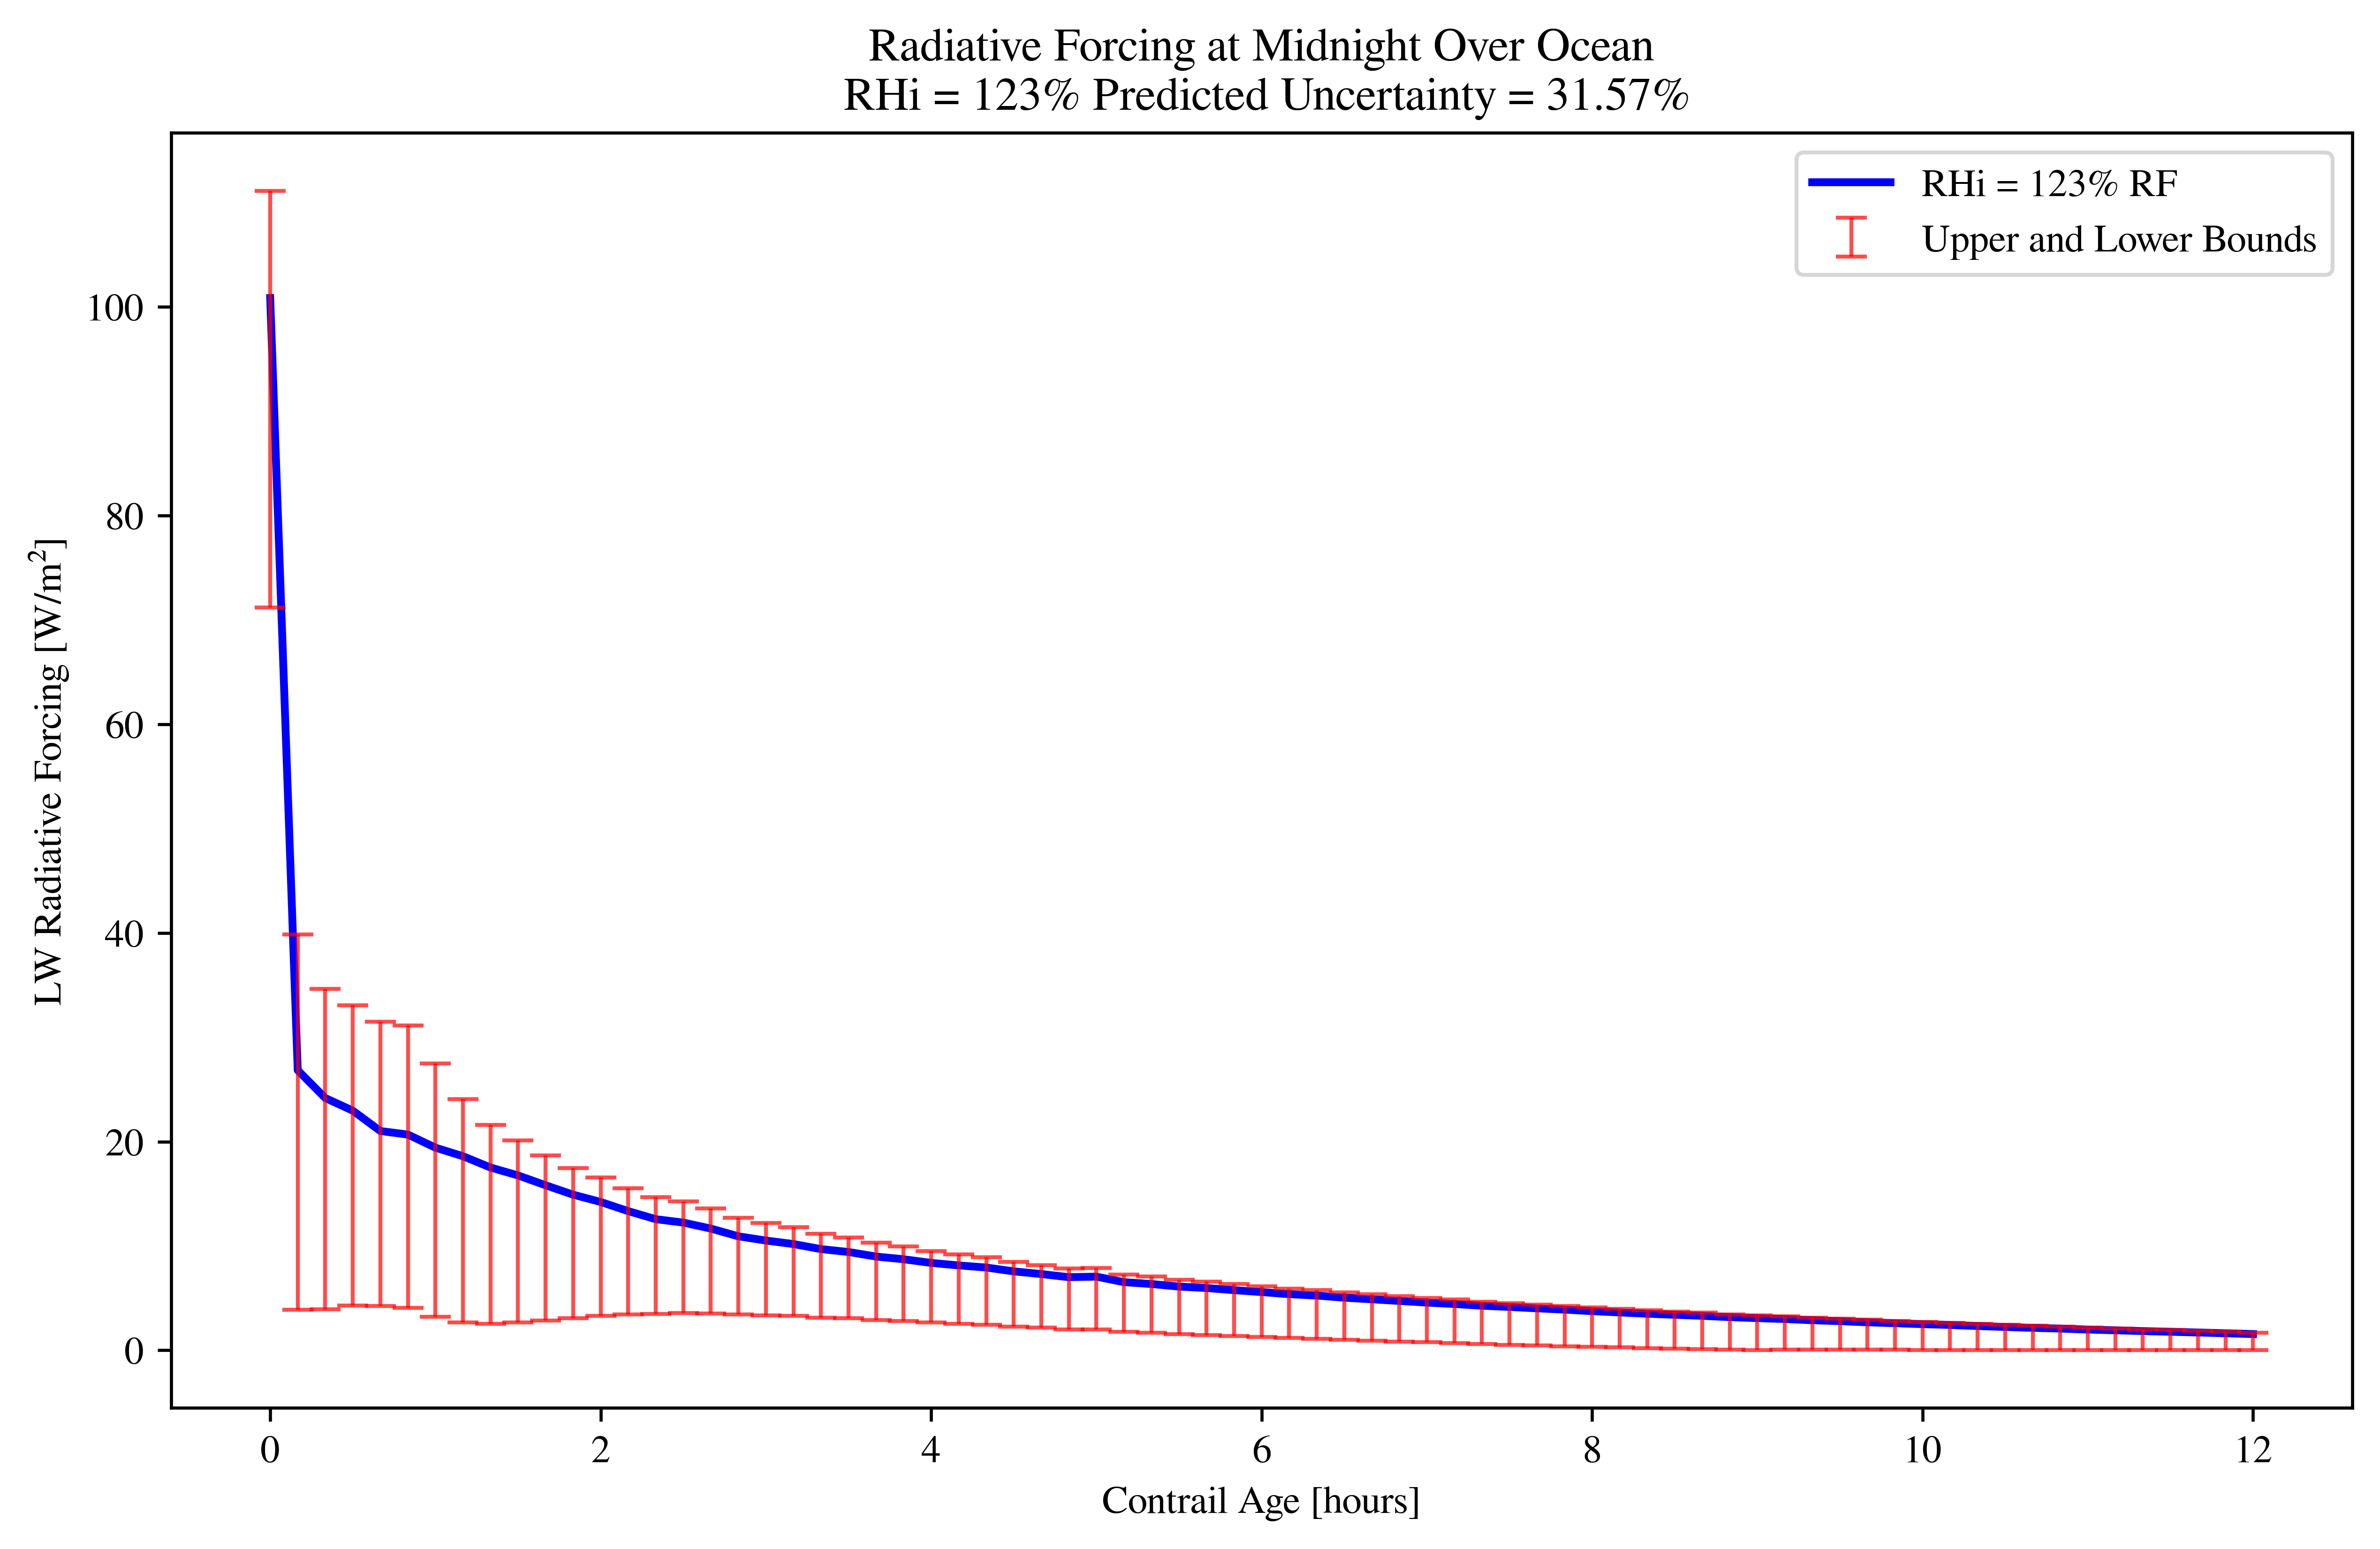

In [28]:
plt.figure(figsize=(10, 6), dpi=600)
plt.plot(LW_RF_APCEMM['Contrail_Age_hours'], LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'], label='RHi = 123% RF', color='blue', linewidth=2)

# Error bars: upper - true, true - lower
y_true = LW_RF_APCEMM['LW_Radiative_Forcing_W_m2'].values
y_lower = LW_RF_APCEMM_lower['LW_Radiative_Forcing_W_m2'].values
y_upper = LW_RF_APCEMM_upper['LW_Radiative_Forcing_W_m2'].values

yerr = [y_true - y_lower, y_upper - y_true]

plt.errorbar(
    LW_RF_APCEMM['Contrail_Age_hours'],
    y_true,
    yerr=yerr,
    fmt='none',
    color='red',
    alpha=0.7,
    linewidth=1,
    label='Upper and Lower Bounds',
    capsize=4
)

plt.xlabel('Contrail Age [hours]')
plt.ylabel('LW Radiative Forcing [W/m²]')
plt.title('Radiative Forcing at Midnight Over Ocean\n RHi = 123% Predicted Uncertainty = 31.57%')
plt.legend()
plt.show()

<!-- ## Compare effects of standard atmospheres on RF -->

<!-- ## Compare effects of ice habits on RF -->